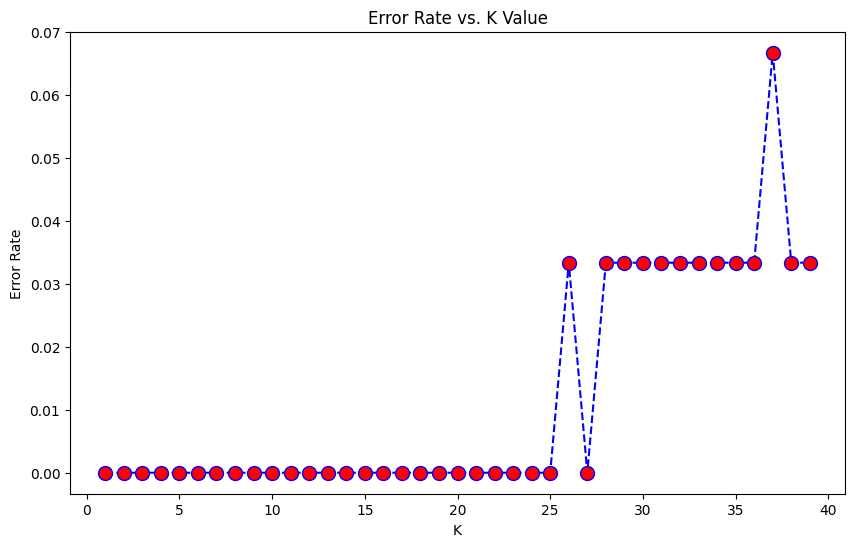

--- Optimal K selected: 1 ---

--- Final Model Evaluation ---
Accuracy: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Dataset and Split
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Find the Optimal K Value (The Elbow Method)
error_rate = []

# Loop through K values from 1 to 39
for i in range(1, 40):
    knn_temp = KNeighborsClassifier(n_neighbors=i)
    knn_temp.fit(X_train_scaled, y_train)
    pred_i = knn_temp.predict(X_test_scaled)
    # Calculate the average error rate for this K
    error_rate.append(np.mean(pred_i != y_test))

# 4. Plot the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# 5. Automatically Select the Best K
# Find the index of the minimum error rate. We add 1 because our loop started at 1.
best_k = error_rate.index(min(error_rate)) + 1
print(f"--- Optimal K selected: {best_k} ---\n")

# 6. Train the Final Model using Best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# 7. Make Predictions and Evaluate
y_pred = knn_final.predict(X_test_scaled)

print("--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

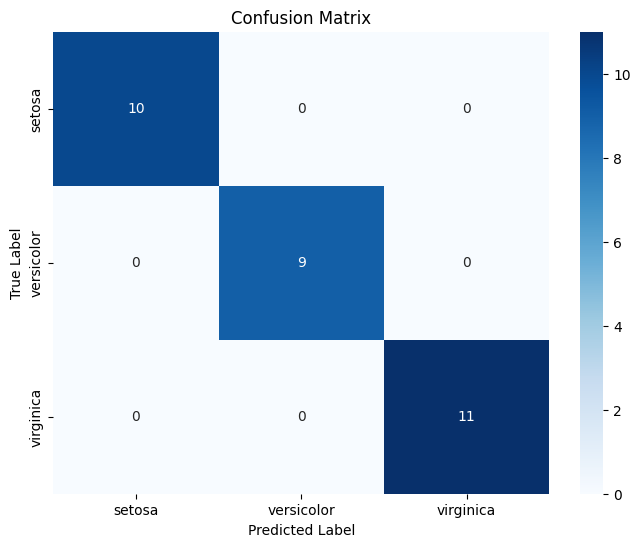

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# The confusion matrix was already computed and is available from the previous cell.
# Let's get the target names for better labeling
target_names = iris.target_names

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Interpreting the Confusion Matrix Visualization

In the heatmap above:

*   **Rows** represent the **True Labels** (actual classes).
*   **Columns** represent the **Predicted Labels** (classes predicted by the model).
*   The **numbers in each cell** indicate the count of instances.

Let's break down the visualized matrix:

*   **Top-Left Cell (True: setosa, Predicted: setosa):** `10`
    *   This means 10 instances that were actually 'setosa' were correctly predicted as 'setosa'. These are **True Positives** for the 'setosa' class.

*   **Middle-Middle Cell (True: versicolor, Predicted: versicolor):** `9`
    *   This means 9 instances that were actually 'versicolor' were correctly predicted as 'versicolor'. These are **True Positives** for the 'versicolor' class.

*   **Bottom-Right Cell (True: virginica, Predicted: virginica):** `11`
    *   This means 11 instances that were actually 'virginica' were correctly predicted as 'virginica'. These are **True Positives** for the 'virginica' class.

*   **All other cells (e.g., True: setosa, Predicted: versicolor):** `0`
    *   A value of `0` in any off-diagonal cell indicates that the model made **no incorrect predictions** for that particular true/predicted class combination.

Since all off-diagonal values are zero, it signifies a **perfect classification** on this test dataset, where every instance was classified into its correct category. This aligns with the 100% accuracy reported earlier.

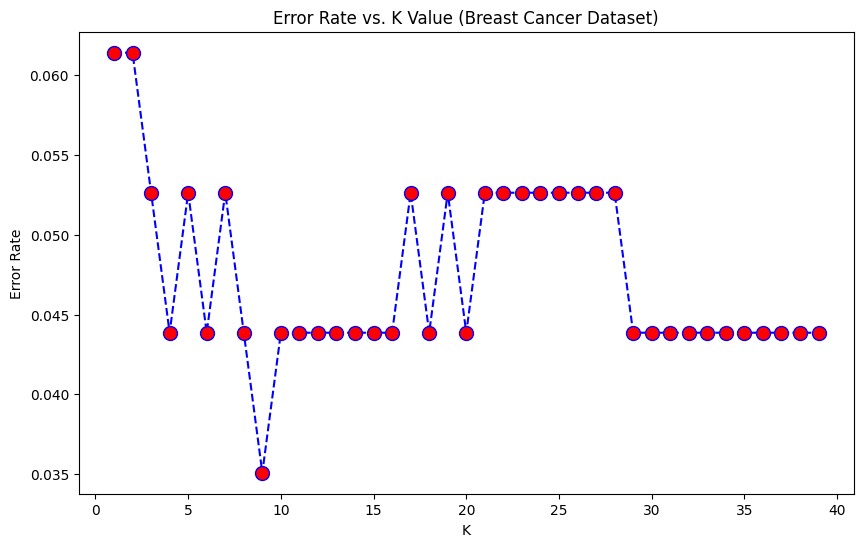

--- Optimal K selected: 9 ---

--- Final Model Evaluation ---
Accuracy: 96.49%

Confusion Matrix:
[[41  2]
 [ 2 69]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        43
      benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Breast Cancer Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# 2. Split the Data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (Absolutely critical for this dataset!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Find the Optimal K Value (The Elbow Method)
error_rate = []

# Loop through K values from 1 to 39
for i in range(1, 40):
    knn_temp = KNeighborsClassifier(n_neighbors=i)
    knn_temp.fit(X_train_scaled, y_train)
    pred_i = knn_temp.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# 5. Plot the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Breast Cancer Dataset)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# 6. Automatically Select the Best K
best_k = error_rate.index(min(error_rate)) + 1
print(f"--- Optimal K selected: {best_k} ---\n")

# 7. Train the Final Model using Best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# 8. Make Predictions and Evaluate
y_pred = knn_final.predict(X_test_scaled)

print("--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
# Target names are 'malignant' (0) and 'benign' (1)
print(classification_report(y_test, y_pred, target_names=cancer.target_names))